**Connor Williams - Midterm**

In [58]:
import sys
import platform
import sklearn
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
import time
from sklearn.metrics import accuracy_score, classification_report
from IPython.display import Image, display





In [59]:
#Task 1
print("Python version:", sys.version)
print("Scikit-Learn version:", sklearn.__version__)
print("Pandas version:", pd.__version__)


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Scikit-Learn version: 1.6.1
Pandas version: 2.2.3


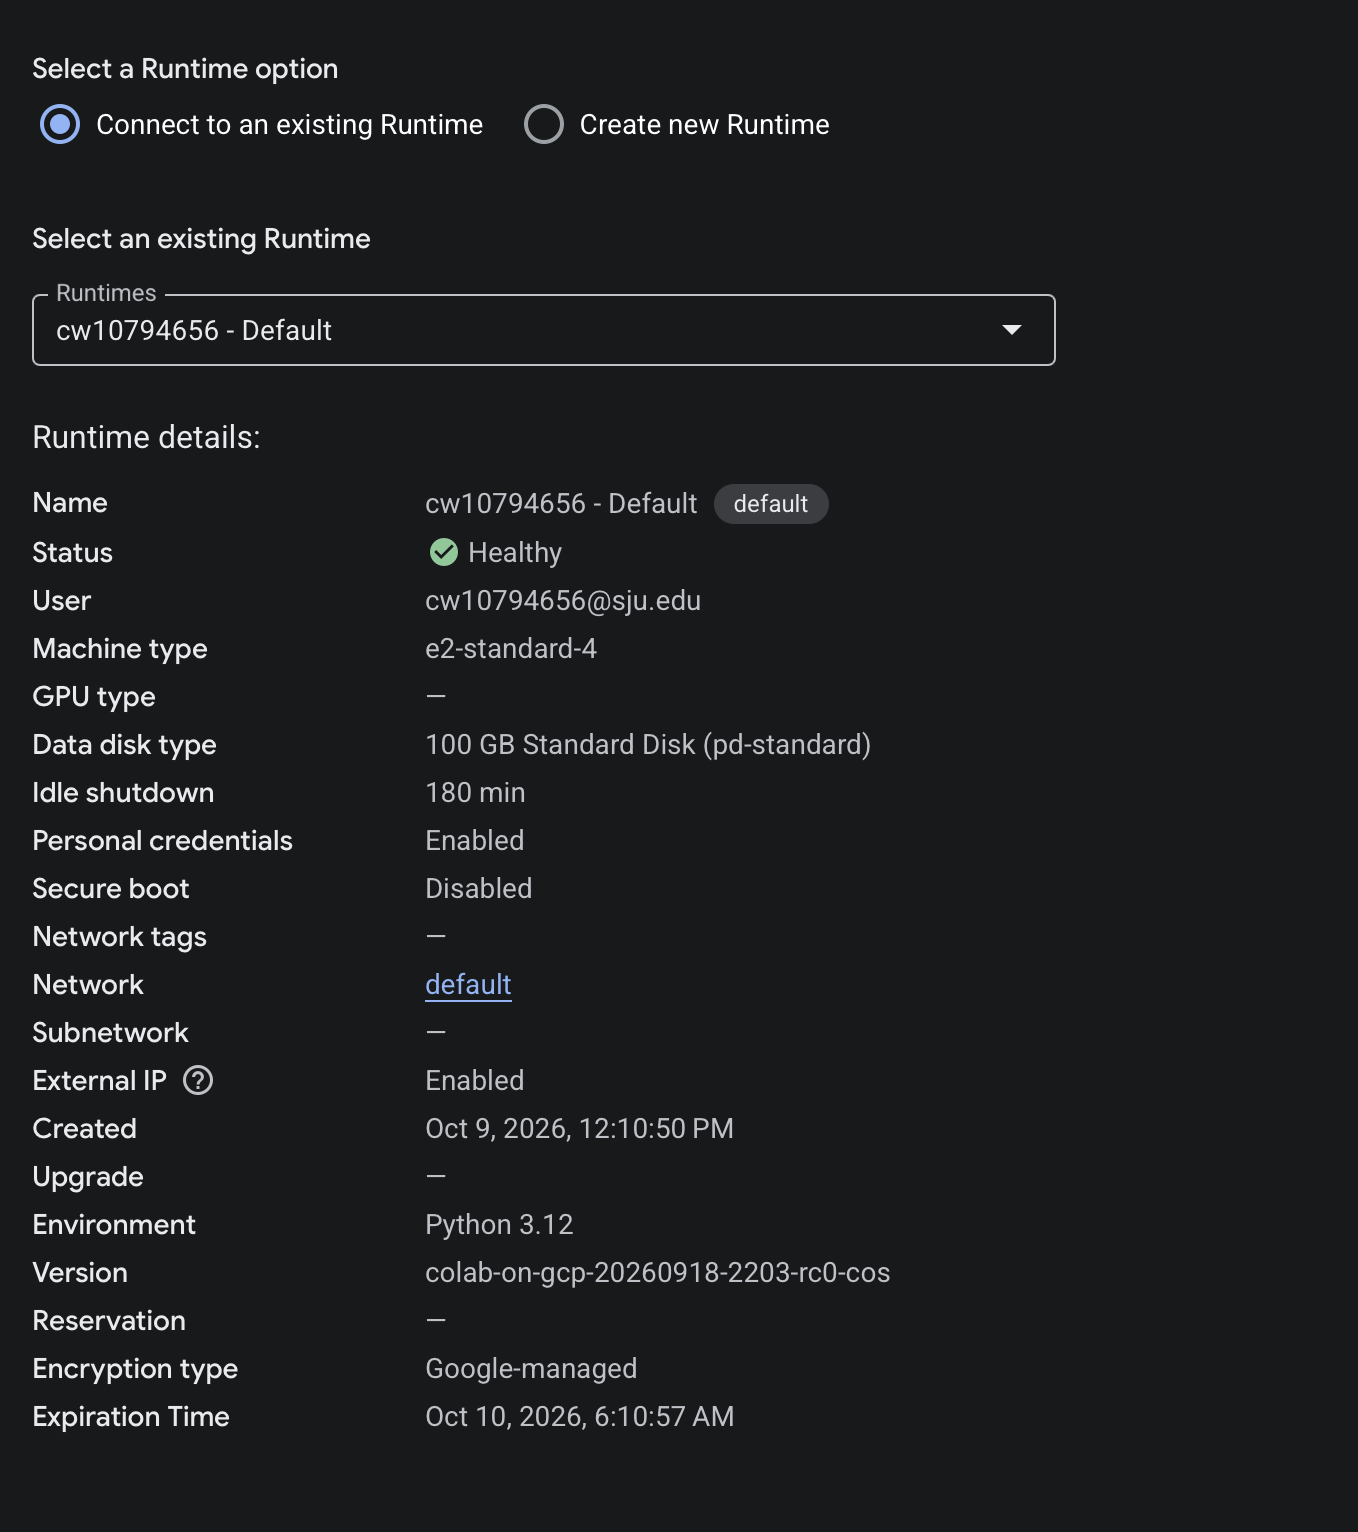

In [60]:
display(Image(filename='/content/Active_Cloud_Runtime.png', width=800))

In [61]:
#Task 2
%pip install -q ucimlrepo

In [62]:
from ucimlrepo import fetch_ucirepo

air_quality = fetch_ucirepo(id=360)
df = air_quality.data.original.copy()


In [63]:
# Task 3
display(df.head())
df.info()
display(df.describe())

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   int64  
 4   NMHC(GT)       9357 non-null   int64  
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   int64  
 7   NOx(GT)        9357 non-null   int64  
 8   PT08.S3(NOx)   9357 non-null   int64  
 9   NO2(GT)        9357 non-null   int64  
 10  PT08.S4(NO2)   9357 non-null   int64  
 11  PT08.S5(O3)    9357 non-null   int64  
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 1.1+ MB


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


In [64]:
#Task 4

df = df.replace(-200, np.nan)

print("Missing values per column:")
print(df.isnull().sum())

imputer = SimpleImputer(strategy='median')
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

Missing values per column:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [65]:
#Task 5
df = air_quality.data.original.copy()
df = df.replace(-200, np.nan)

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)

Numerical features: ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
Categorical features: ['Date', 'Time']


In [66]:
#6
data = df.dropna(subset=['CO(GT)']).copy()
#Binning converts CO concentrations into three categories
#0 = Low, 1 = Moderate, and 2 = High.
data['AirQuality'] = pd.qcut(
    data['CO(GT)'], q=3, labels=[0, 1, 2],
    duplicates='drop').astype(int)

X = data.drop(columns=['CO(GT)', 'AirQuality', 'Date', 'Time'])
y = data['AirQuality']

num_features = X.select_dtypes(include='number').columns.tolist()

model_preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Softmax Regression': LogisticRegression(
        solver='lbfgs', max_iter=1000
    ),
    'SGDClassifier': SGDClassifier(
        loss='log_loss', alpha=0.0001,
        max_iter=1000, tol=0.001, random_state=42
    )
}

for name, classifier in models.items():
    model = Pipeline([
        ('preprocessor', model_preprocessor),
        ('classifier', classifier)
    ])

    start = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start

    predictions = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print("Training time:", round(training_time, 3), "seconds")
    print(classification_report(y_test, predictions))


 Logistic Regression
Accuracy: 0.8749185667752443
Training time: 0.137 seconds
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       525
           1       0.81      0.82      0.82       501
           2       0.91      0.90      0.91       509

    accuracy                           0.87      1535
   macro avg       0.87      0.87      0.87      1535
weighted avg       0.88      0.87      0.88      1535


 Softmax Regression
Accuracy: 0.8749185667752443
Training time: 0.147 seconds
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       525
           1       0.81      0.82      0.82       501
           2       0.91      0.90      0.91       509

    accuracy                           0.87      1535
   macro avg       0.87      0.87      0.87      1535
weighted avg       0.88      0.87      0.88      1535


 SGDClassifier
Accuracy: 0.8599348534201955
Training time: 0.114 seconds
     

In [67]:
#7
reg_data = df.dropna(subset=['CO(GT)']).copy()

X_reg = reg_data.drop(columns=['CO(GT)', 'Date', 'Time'])
y_reg = reg_data['CO(GT)']

# This splits data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (0.1)': Ridge(alpha=0.1),
    'Ridge (1)': Ridge(alpha=1),
    'Ridge (10)': Ridge(alpha=10),
    'Lasso (0.01)': Lasso(alpha=0.01, max_iter=10000),
    'Lasso (0.1)': Lasso(alpha=0.1, max_iter=10000),
    'Lasso (1)': Lasso(alpha=1, max_iter=10000)
}

results = []

for name, regressor in reg_models.items():

    model = Pipeline([
        ('preprocessor', model_preprocessor),
        ('regressor', regressor)
    ])

    model.fit(X_train_reg, y_train_reg)
    predictions = model.predict(X_test_reg)

    coefficients = model.named_steps['regressor'].coef_

    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, predictions)),
        'R2': r2_score(y_test_reg, predictions),
        'Zero Coefficients': np.sum(np.isclose(coefficients, 0, atol=1e-8))
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,RMSE,R2,Zero Coefficients
0,Linear Regression,0.471774,0.893142,0
1,Ridge (0.1),0.471776,0.893142,0
2,Ridge (1),0.471789,0.893136,0
3,Ridge (10),0.471936,0.893069,0
4,Lasso (0.01),0.478346,0.890145,1
5,Lasso (0.1),0.528095,0.866106,7
6,Lasso (1),1.188219,0.322157,11


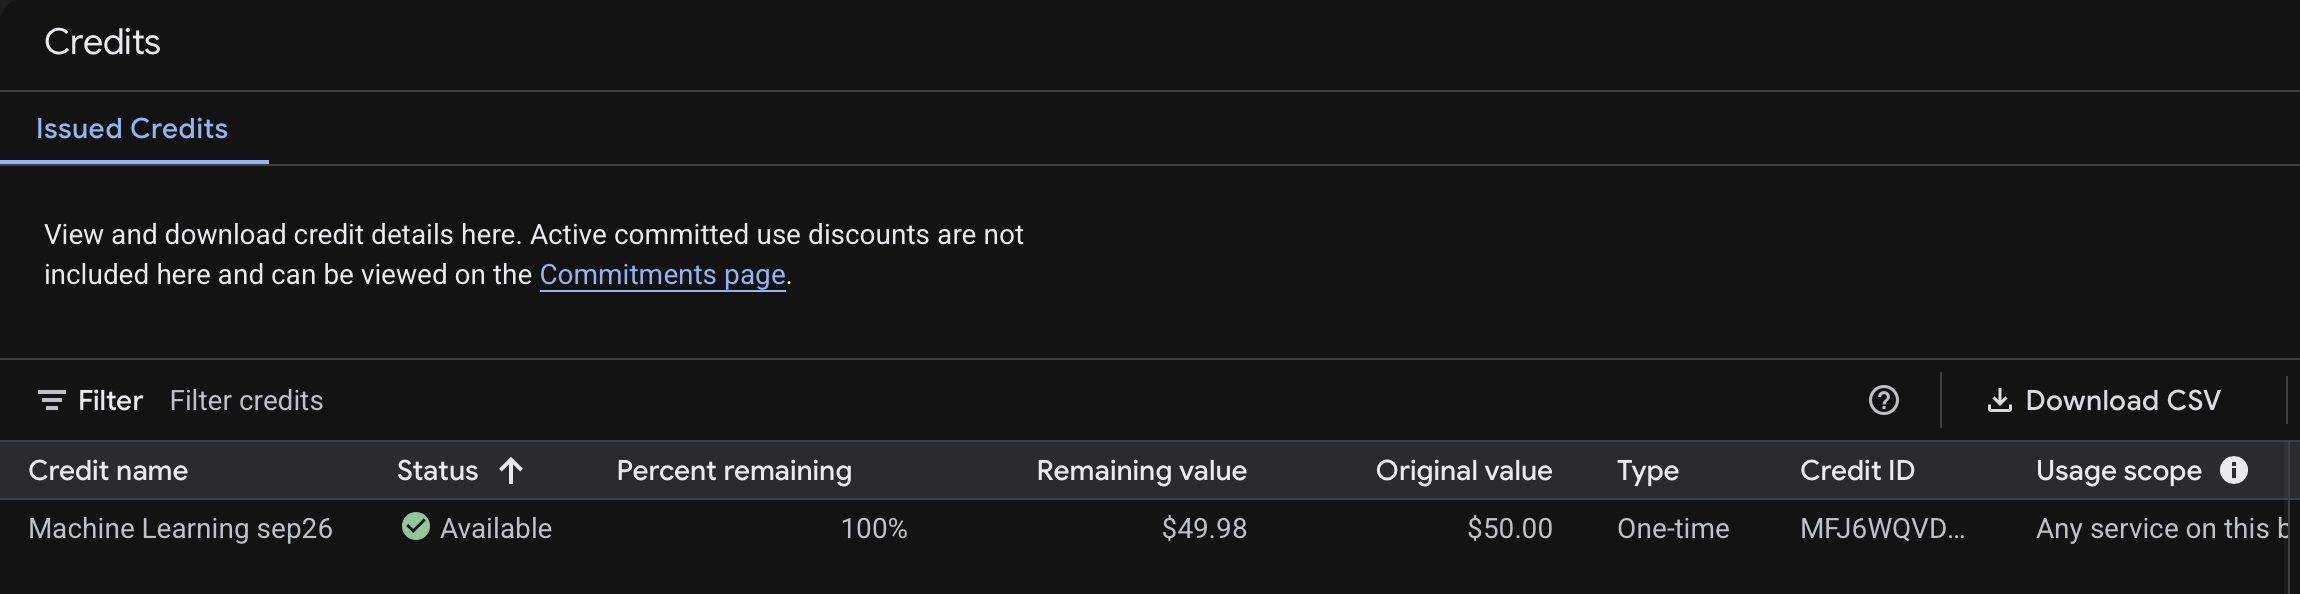

In [68]:
#8
display(Image(filename='/content/CreditUsage.png', width=800))

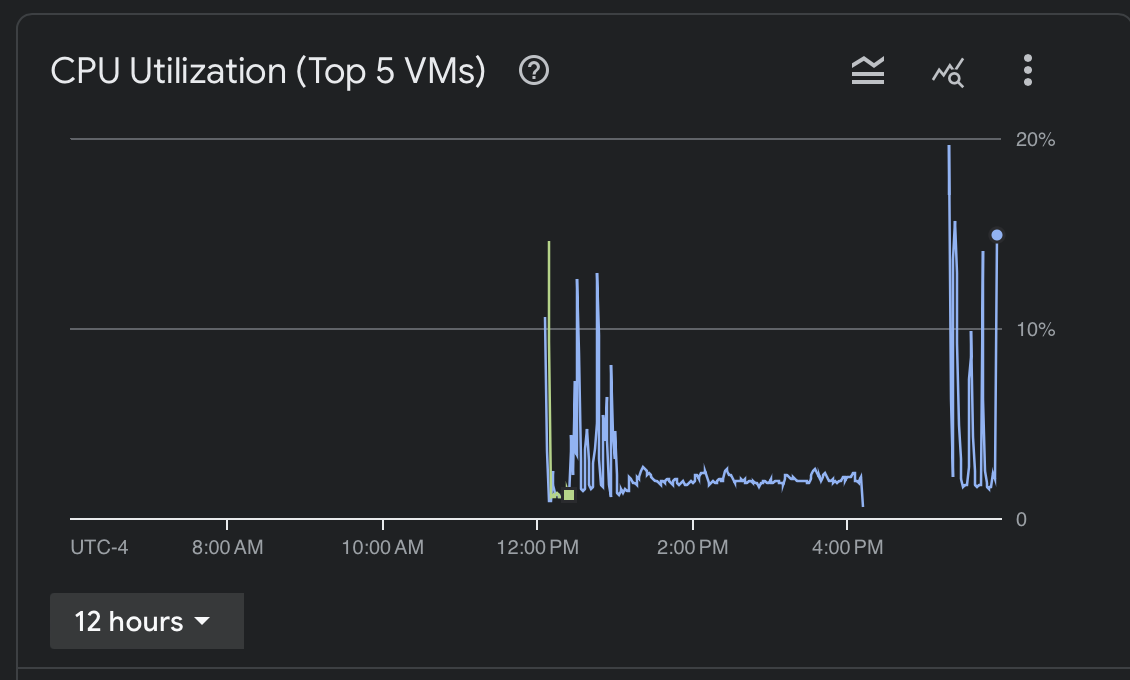

In [69]:
display(Image(filename='/content/Resource_Utilization.png', width=800))
#This is CPU utilization but I was not able to find the resource utilization dashboard

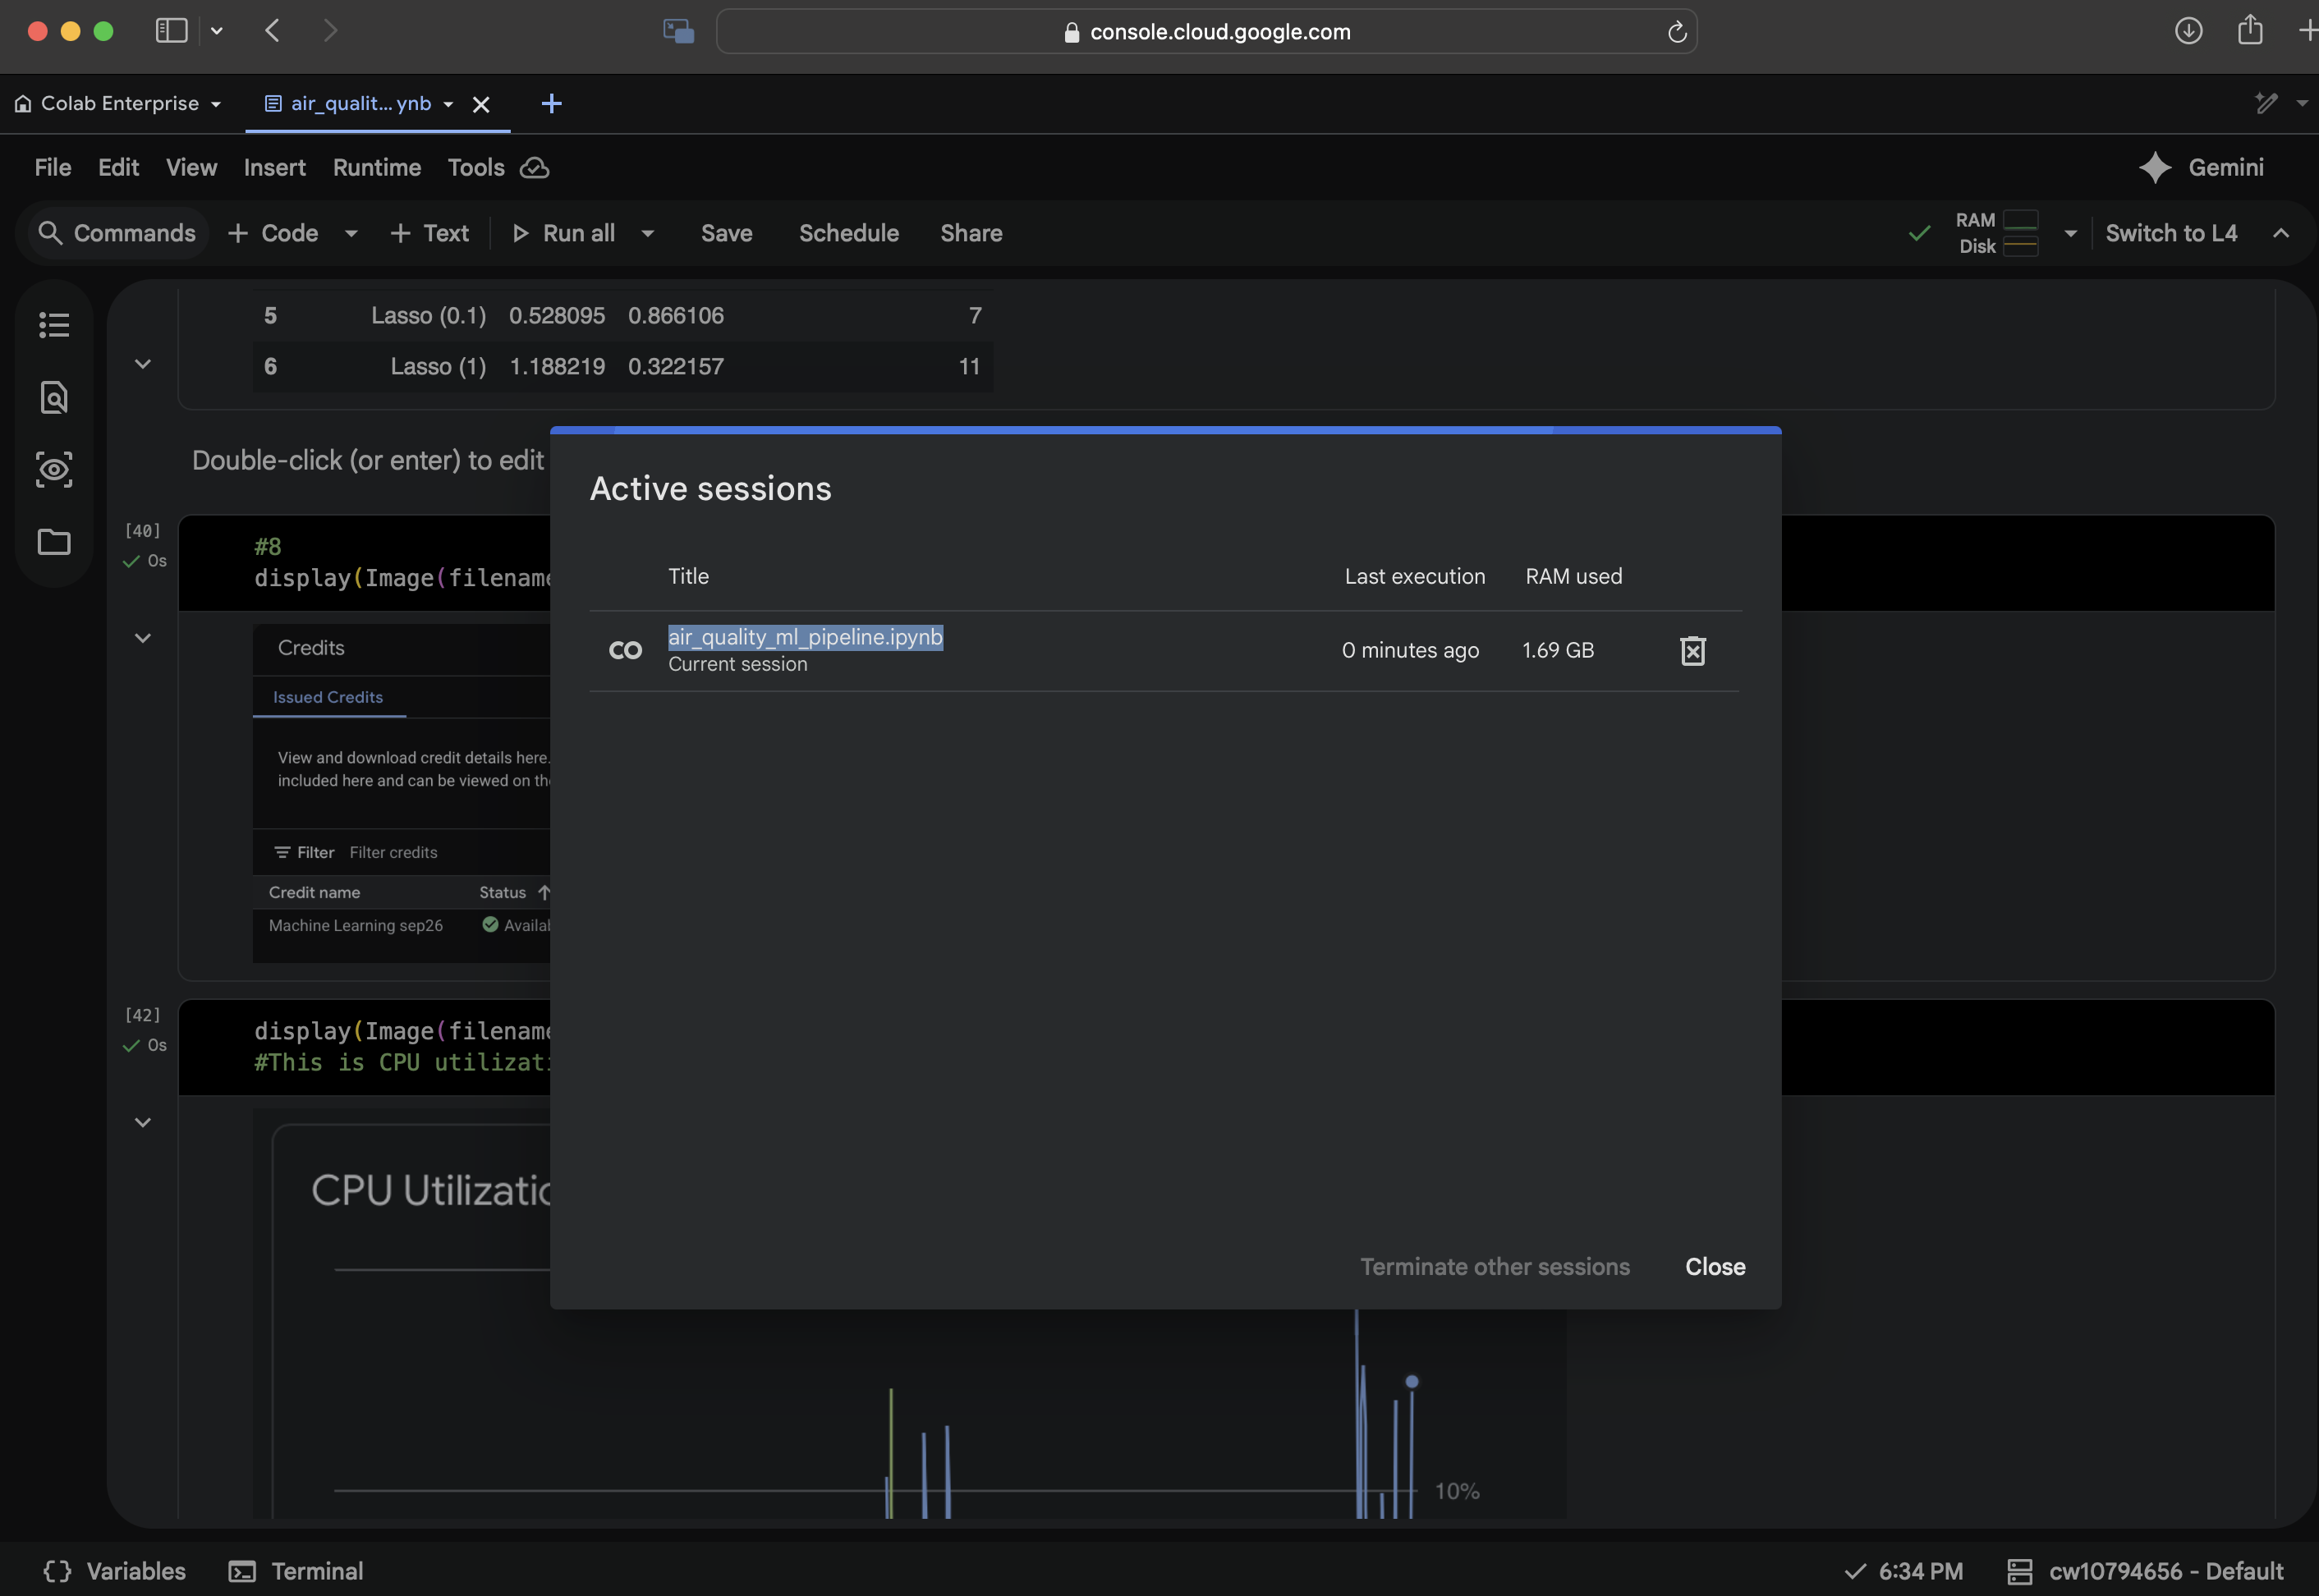

In [70]:
display(Image(filename='/content/runtime.png', width=800))
